# **Mini-Projeto Avaliativo para o curso de Visualização de Dados e BI do programa SCTEC.**

Entregar um script em Python que realize uma Análise Exploratória da base Varejo seguindo etapas claras, documentadas e reproduzíveis.

Etapas obrigatórias:
* Carregar a base Varejo.csv com pandas e mostrar: número de registros, colunas e tipos de dados.
* Verificar e reportar ao menos dois problemas básicos: valores nulos por coluna, duplicatas e possíveis inconsistências (ex.: datas inválidas ou categorias vazias).
* Fazer as três etapas de limpeza mínima necessária: remover ou imputar nulos (explique a escolha), eliminar duplicatas relevantes e ajustar tipos de dados (ex.: converter coluna DATA para datetime).
* Gerar estatísticas descritivas básicas para coluna de número de filhos do cliente (média; mediana; desvio padrão; moda; máximo; mínimo; e contagem).
* Explorar padrões de agrupamento com pelo menos dois agrupamentos (por exemplo: gênero com mais vendas, compras), usando groupby() ou pivot_table().
* Produzir um pequeno bloco de conclusões (3–6 tópicos) com os principais insights obtidos e possíveis problemas remanescentes na base.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/namespaiva/base-varejo/Base Varejo.csv", delimiter=";")

df

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829995,19/08/2022,919822,155,F,2,0,B,183,ALIMENTOS,KETCHUP,NaN,NaN,NaN,NaN
829996,19/08/2022,919822,155,F,2,0,B,56,ALIMENTOS,QUEIJO MUSSARELA,NaN,NaN,NaN,NaN
829997,19/08/2022,919822,155,F,2,0,B,227,ALIMENTOS,ARROZ,NaN,NaN,NaN,NaN
829998,19/08/2022,919822,155,F,2,0,B,214,ALIMENTOS,CEBOLA,NaN,NaN,NaN,NaN


# Análise rápida 
O Dataframe não tem um ID/chave única

As últimas 4 colunas visivelmente tem dados vazios. 

Lista de colunas retirada da documentação do dataset:
* DATA: Data da compra
* CO_ID: Identificação do número de compra (número da nota fiscal)
* CL_ID: Identificação do cliente (número do cliente)
* CL_GENERO: Sexo biológico informado pelo cliente
* CL_EC: Estado civil do cliente: 1 - Casado ou união estával, 2 - Divorciado, 3 - Separado, 4 - Solteiro, 5 - Viúvo)
* CL_FHL: Número de filhos do cliente
* CL_SEG: Segmentação econômica do cliente (classe A, B ou C)
* PR_ID: Código do produto (SKU) adquirido
* PR_CAT: Categoria do produto adquirido
* PR_NOME: Nome do produto adquirido

In [2]:
df.info()
# A base está com dados nulos nas últimas 4 colunas.
# Total de 830.000 registros.
# O campo data pode ser convertido para tipo Datetime, facilitando a sua posterior manipulação.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  object 
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  object 
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  object 
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  object 
 9   PR_NOME      830000 non-null  object 
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), object(5)
memory usage: 88.7+ MB


In [3]:
# Excluir as últimas 4 colunas vazias
df = df.drop(columns=['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'])

In [4]:
df.isnull().sum()
# Verificando se além das 4 últimas colunas, existem outras com campos vazios. 
# Confirmado que não constam dados vazios.

DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

# Atualizando os tipos de colunas correspondentes aos dados das colunas
Neste dataset será transformada a coluna DATA que chegou como tipo object e será modificada para o tipo datetime. Desta forma é possível manipular o campo para montar relatórios estratégicos de vendas

In [5]:
# Passa para string, remove espaços vazios e força a conversão novamente para o tipo string
df['DATA'] = df['DATA'].astype(str).str.strip()

# Conversão da coluna para o tipo datatime
df['DATA'] = pd.to_datetime(df['DATA'], format='%d/%m/%Y', errors='coerce')

df

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO
...,...,...,...,...,...,...,...,...,...,...
829995,2022-08-19,919822,155,F,2,0,B,183,ALIMENTOS,KETCHUP
829996,2022-08-19,919822,155,F,2,0,B,56,ALIMENTOS,QUEIJO MUSSARELA
829997,2022-08-19,919822,155,F,2,0,B,227,ALIMENTOS,ARROZ
829998,2022-08-19,919822,155,F,2,0,B,214,ALIMENTOS,CEBOLA


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       830000 non-null  datetime64[ns]
 1   CO_ID      830000 non-null  int64         
 2   CL_ID      830000 non-null  int64         
 3   CL_GENERO  830000 non-null  object        
 4   CL_EC      830000 non-null  int64         
 5   CL_FHL     830000 non-null  int64         
 6   CL_SEG     830000 non-null  object        
 7   PR_ID      830000 non-null  int64         
 8   PR_CAT     830000 non-null  object        
 9   PR_NOME    830000 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage: 63.3+ MB


# Verificando e tratando linhas com dados duplicados

In [7]:
df.duplicated().sum()
# A base possui 96.553 registros duplicados. 

np.int64(96553)

In [8]:
# Excluir os registros duplicados
df = df.drop_duplicates()

In [9]:
df.info() # 733.447 registros

<class 'pandas.core.frame.DataFrame'>
Index: 733447 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       733447 non-null  datetime64[ns]
 1   CO_ID      733447 non-null  int64         
 2   CL_ID      733447 non-null  int64         
 3   CL_GENERO  733447 non-null  object        
 4   CL_EC      733447 non-null  int64         
 5   CL_FHL     733447 non-null  int64         
 6   CL_SEG     733447 non-null  object        
 7   PR_ID      733447 non-null  int64         
 8   PR_CAT     733447 non-null  object        
 9   PR_NOME    733447 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage: 61.6+ MB


# Verificando se os campos (principalmente do tipo string), tem algum valor fora do padrão e que precisem ser padronizados

In [10]:
# Renomear colunas para identificar de forma mais claro a qual dado se refere 
df = df.rename(columns={
    "DATA": "DT_COMPRA", 
    "CO_ID": "ID_COMPRA",
    "CL_ID": "ID_CLIENTE",
    "CL_GENERO": "CO_GENERO",
    "CL_EC": "CO_ESTADO_CIVIL",
    "CL_FHL": "QT_FILHOS",
    "CL_SEG": "CO_SEGMENTO",
    "PR_ID": "ID_PRODUTO",
    "PR_CAT": "DE_CATEGORIA_PRODUTO",
    "PR_NOME": "NM_PRODUTO"    
})

**Referência para a coluna CO_ESTADO_CIVIL**

1. Casado ou união estával
2. Divorciado
3. Separado
4. Solteiro
5. Viúvo

In [11]:
# Padronizar os dados do tipo string para retirar espaços em branco (no inio e fim) e, neste caso, manter todo em caixa alta. 
# Consultei fórmula por IA, via Google
colunas_string = df.select_dtypes(include=['object']).columns
#df[colunas_string] = df[colunas_string].apply(lambda x: x.astype(object).str.strip())

# Use o .loc com ":" para indicar "todas as linhas" e passe a lista de colunas
df.loc[:, colunas_string] = df[colunas_string].apply(lambda x: x.astype(str).str.strip())


In [12]:
# Alterar o tipo de dado da coluna CD_ESTADO_CIVIL de int para object
df['CO_ESTADO_CIVIL'] = df['CO_ESTADO_CIVIL'].astype(str)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 733447 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   DT_COMPRA             733447 non-null  datetime64[ns]
 1   ID_COMPRA             733447 non-null  int64         
 2   ID_CLIENTE            733447 non-null  int64         
 3   CO_GENERO             733447 non-null  object        
 4   CO_ESTADO_CIVIL       733447 non-null  object        
 5   QT_FILHOS             733447 non-null  int64         
 6   CO_SEGMENTO           733447 non-null  object        
 7   ID_PRODUTO            733447 non-null  int64         
 8   DE_CATEGORIA_PRODUTO  733447 non-null  object        
 9   NM_PRODUTO            733447 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 61.6+ MB


In [14]:
# Atualizados os dados para que já mostre o nome do estado civil. Dessa forma, a informação fica mais visível de identificar nos relatórios
df['CO_ESTADO_CIVIL'] = df['CO_ESTADO_CIVIL'].replace('1', 'CASADO OU UNIAO ESTAVEL')
df['CO_ESTADO_CIVIL'] = df['CO_ESTADO_CIVIL'].replace('2', 'DIVORCIADO')
df['CO_ESTADO_CIVIL'] = df['CO_ESTADO_CIVIL'].replace('3', 'SEPARADO')
df['CO_ESTADO_CIVIL'] = df['CO_ESTADO_CIVIL'].replace('4', 'SOLTEIRO')
df['CO_ESTADO_CIVIL'] = df['CO_ESTADO_CIVIL'].replace('5', 'VIUVO')

In [15]:
df['CO_ESTADO_CIVIL'].value_counts()

CO_ESTADO_CIVIL
SEPARADO                   189048
SOLTEIRO                   179206
DIVORCIADO                 172283
CASADO OU UNIAO ESTAVEL    172010
VIUVO                       20900
Name: count, dtype: int64

In [16]:
df['CO_GENERO'].value_counts()
# Já podemos perceber que tem quase a mesma quantidade de clientes do sexo feminino como do masculino
# O feminino ultrapassa um pouco mais da metade

CO_GENERO
F    382427
M    351020
Name: count, dtype: int64

In [17]:
df['CO_SEGMENTO'].value_counts()
# Percebemos que o maior público é de clientes da classe B

CO_SEGMENTO
B    468505
C    205265
A     59677
Name: count, dtype: int64

In [18]:
df['DE_CATEGORIA_PRODUTO'].value_counts()
# Quase que a maioria dos produtos vendidos são da categoria de Alimentos

DE_CATEGORIA_PRODUTO
ALIMENTOS     384197
HIGIENE       137702
LIMPEZA       128632
BEBIDAS        38264
PET            28553
ACESSORIOS     12871
#N/D            3228
Name: count, dtype: int64

In [19]:
# Pesquisado para ter uma visão de como está a escrita dos produtos, por padrão ordena por quantidade
df['NM_PRODUTO'].value_counts()
# Vemos que o Presunto é o produto que tem maior venda. Quase o dobro comparando com os produtos mais vendidos na sequência.

NM_PRODUTO
PRESUNTO COZIDO          12719
SARDINHA                  6610
ESCOVA DE DENTE           6518
BANANA                    6518
GEL                       6517
                         ...  
#N/D                      3228
ABSORVENTE                3220
ALIMENTO PARA PASSARO     3198
ALHO                      3194
ALCOOL                    3168
Name: count, Length: 118, dtype: int64

In [20]:
df[colunas_string]

,CO_GENERO,CO_SEGMENTO,DE_CATEGORIA_PRODUTO,NM_PRODUTO
0,M,C,BEBIDAS,REFRIGERANTE GUARANA
1,M,C,BEBIDAS,REFRIGERANTE OUTROS
2,M,C,HIGIENE,LENCO UMEDECIDO
3,M,C,ALIMENTOS,ABACAXI
4,M,C,LIMPEZA,LIMPADOR MULTIUSO
...,...,...,...,...
829991,F,B,HIGIENE,PRESERVATIVO
829993,F,B,ALIMENTOS,SNACKS
829994,F,B,ALIMENTOS,AZEITE
829998,F,B,ALIMENTOS,CEBOLA


# **Análises estatísticas**


In [21]:
df.describe()

,DT_COMPRA,ID_COMPRA,ID_CLIENTE,QT_FILHOS,ID_PRODUTO
count,733447,733447.000000,733447.000000,733447.000000,733447.000000
mean,2020-12-06 11:20:27.215054336,459941.034680,499.643996,1.146049,115.037337
min,2019-01-04 00:00:00,1000.000000,1.000000,0.000000,1.000000
25%,2020-01-09 00:00:00,232895.000000,254.000000,0.000000,58.000000
50%,2020-12-27 00:00:00,456422.000000,498.000000,0.000000,115.000000
75%,2021-10-20 00:00:00,690100.000000,746.000000,2.000000,172.000000
max,2022-12-08 00:00:00,919822.000000,1000.000000,4.000000,229.000000
std,NaN,265431.394822,287.561653,1.416917,66.124263


# Relatório com a quantidade de produtos vendidos para cada ano

In [22]:
vendas_por_ano = df.groupby(
    df['DT_COMPRA'].dt.year).agg(
        TOTAL_PROD_VENDIDOS=('ID_PRODUTO', 'count')
)
        
vendas_por_ano['PORC_VENDAS_ANO (%)'] = (
    vendas_por_ano['TOTAL_PROD_VENDIDOS']
    / vendas_por_ano['TOTAL_PROD_VENDIDOS'].sum() * 100
).round(2)

print(vendas_por_ano.sort_values(by='PORC_VENDAS_ANO (%)', ascending=False))

           TOTAL_PROD_VENDIDOS  PORC_VENDAS_ANO (%)
DT_COMPRA                                          
2021                    216813                29.56
2020                    192804                26.29
2019                    176103                24.01
2022                    147727                20.14


# Relatório com a quantidade de produtos vendidos por mês, ordenado pelos meses de maior a menor venda

O mês que menos vendeu foi Novembro. Pouco menos da metade de produtos vendidos comparado aos melhores meses.

In [23]:
vendas_por_mes = df.groupby(
    df['DT_COMPRA'].dt.month).agg(
        TOTAL_PROD_VENDIDOS=('ID_PRODUTO', 'count')
)
        
vendas_por_mes['PORC_VENDAS_MES (%)'] = (
    vendas_por_mes['TOTAL_PROD_VENDIDOS']
    / vendas_por_mes['TOTAL_PROD_VENDIDOS'].sum() * 100
).round(2)

print(vendas_por_mes.sort_values(by='PORC_VENDAS_MES (%)', ascending=False))

           TOTAL_PROD_VENDIDOS  PORC_VENDAS_MES (%)
DT_COMPRA                                          
1                        74121                10.11
5                        72799                 9.93
2                        67130                 9.15
10                       65350                 8.91
12                       62330                 8.50
7                        60936                 8.31
9                        60687                 8.27
6                        59848                 8.16
4                        59220                 8.07
8                        58022                 7.91
3                        56929                 7.76
11                       36075                 4.92


# Relação de quantidade de filhos e compras realizadas

In [24]:
relacao_qtd_filhos_compras = df.groupby(
    ['QT_FILHOS']).agg(
        TOTAL_PROD_VENDIDOS=('ID_PRODUTO', 'count')
)

relacao_qtd_filhos_compras['PORC_PROD_VENDIDOS (%)'] = (
    relacao_qtd_filhos_compras['TOTAL_PROD_VENDIDOS']
    / relacao_qtd_filhos_compras['TOTAL_PROD_VENDIDOS'].sum() * 100
).round(2)

print(relacao_qtd_filhos_compras.sort_values(by='PORC_PROD_VENDIDOS (%)', ascending=False))

           TOTAL_PROD_VENDIDOS  PORC_PROD_VENDIDOS (%)
QT_FILHOS                                             
0                       384986                   52.49
2                        94168                   12.84
3                        92407                   12.60
1                        90845                   12.39
4                        71041                    9.69


# Gráfico mostrando evolução dos produtos vendidos mês a mês

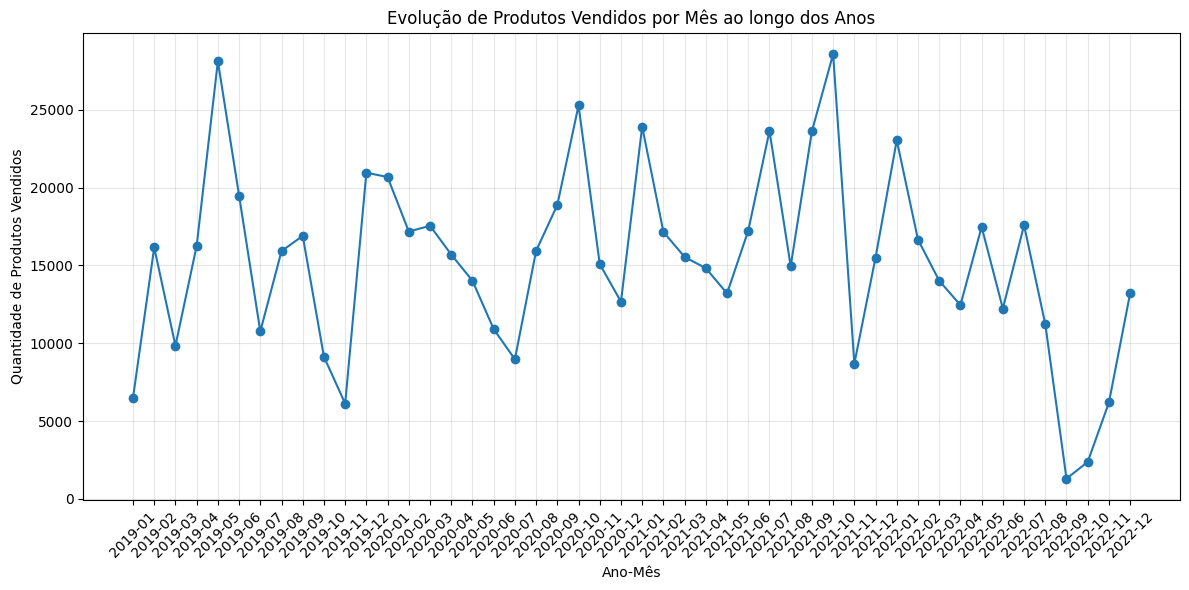

In [25]:
# Montando com ajuda de IA

# Cria a coluna ANO_MES no formato yyyy-mm
df['ANO_MES'] = df['DT_COMPRA'].dt.to_period('M').astype(str)

# Agrupa e contabiliza a quantidade de produtos vendidos por mês
evolucao_vendas = df.groupby('ANO_MES').agg(
    TOTAL_PROD_VENDIDOS=('ID_PRODUTO', 'count')
).reset_index()

# Garante que está ordenado cronologicamente
evolucao_vendas = evolucao_vendas.sort_values('ANO_MES')

# Plota o gráfico
plt.figure(figsize=(12, 6))
plt.plot(evolucao_vendas['ANO_MES'], evolucao_vendas['TOTAL_PROD_VENDIDOS'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('Ano-Mês')
plt.ylabel('Quantidade de Produtos Vendidos')
plt.title('Evolução de Produtos Vendidos por Mês ao longo dos Anos')
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico comparando as vendas entre os meses para cada ano

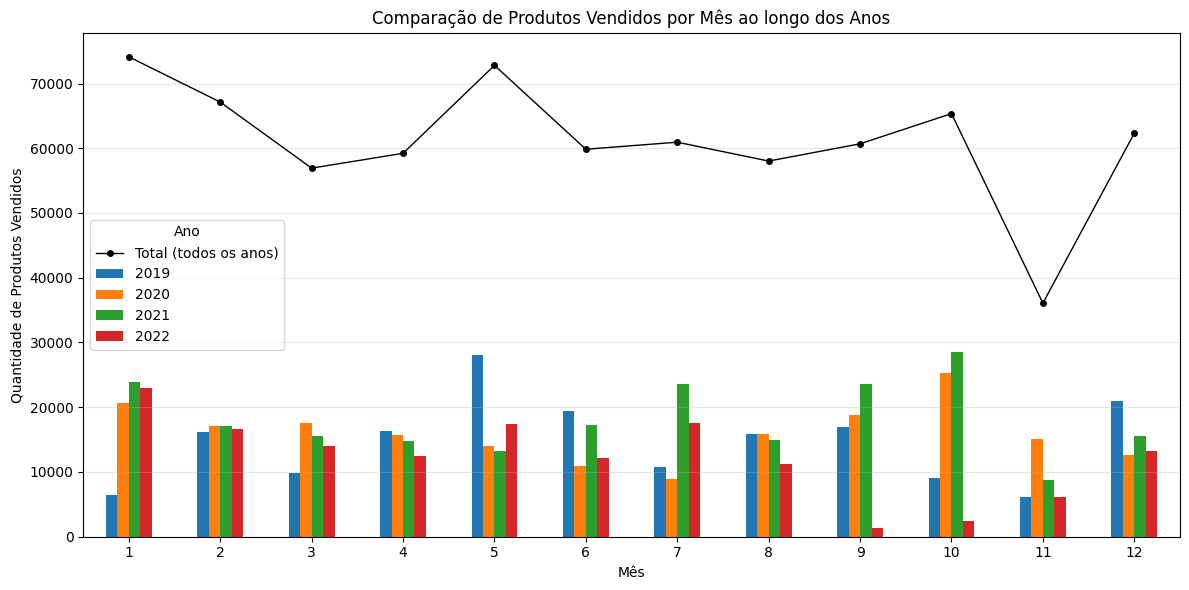

In [26]:
# Montando com ajuda de IA

# Extrai ano e mês separadamente
df['ANO'] = df['DT_COMPRA'].dt.year
df['MES'] = df['DT_COMPRA'].dt.month

# Agrupa por ano e mês, contabilizando os produtos vendidos
evolucao_mensal = df.groupby(['ANO', 'MES']).agg(
    TOTAL_PROD_VENDIDOS=('ID_PRODUTO', 'count')
).reset_index()

# Faz o pivot: meses no eixo x e anos nas colunas coloridas
pivot_evolucao = evolucao_mensal.pivot(index='MES', columns='ANO', values='TOTAL_PROD_VENDIDOS')

# Cria a figura e o eixo
fig, ax = plt.subplots(figsize=(12, 6))

# Gráfico de barras agrupadas
pivot_evolucao.plot(kind='bar', ax=ax)

# Linha fina mostrando o total (soma de todos os anos) por mês
total_por_mes = pivot_evolucao.sum(axis=1)
ax.plot(range(len(total_por_mes)), total_por_mes.values,
        color='black', linewidth=1, linestyle='-', marker='o', markersize=4,
        label='Total (todos os anos)')

ax.set_xlabel('Mês')
ax.set_ylabel('Quantidade de Produtos Vendidos')
ax.set_title('Comparação de Produtos Vendidos por Mês ao longo dos Anos')
ax.set_xticklabels(pivot_evolucao.index, rotation=0)
ax.legend(title='Ano')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Produtos vendidos por Categoria e Genero')

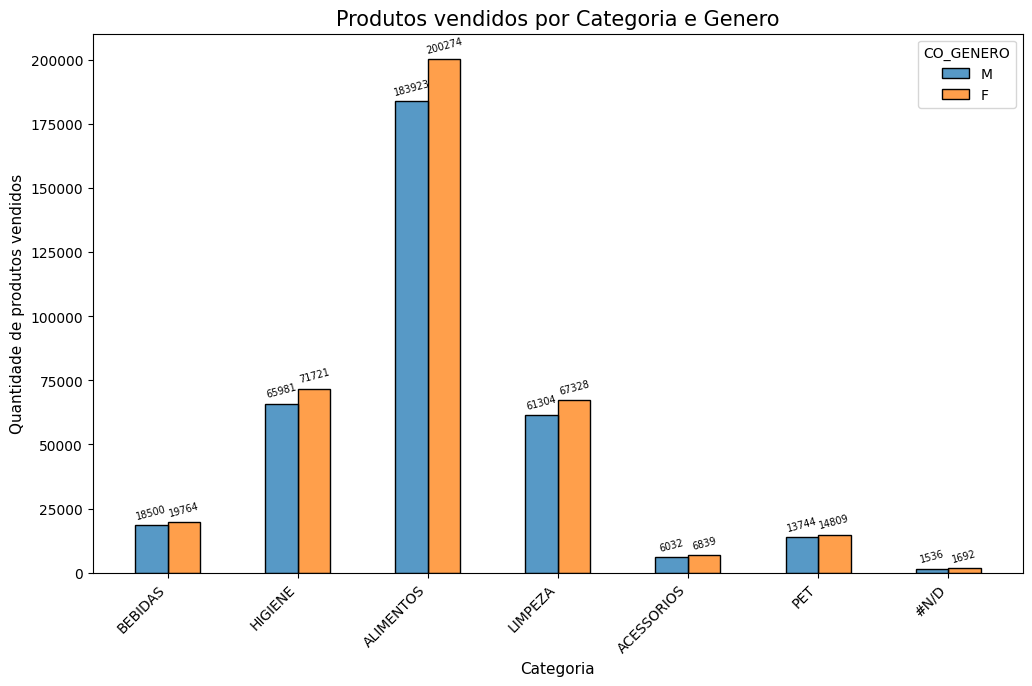

In [27]:
# Aumenta o tamanho do gráfico
plt.figure(figsize=(12, 7))

# Gráfico para visualizar
ax = sns.histplot(data=df, x="DE_CATEGORIA_PRODUTO", hue="CO_GENERO", multiple="dodge", shrink=0.5, legend=True)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%g",  # Formata o número (ex: remove decimais desnecessários)
        padding=3,  # Espaçamento em pontos entre o topo da barra e o texto
        fontsize=7,  # Tamanho da fonte do valor
        rotation=15,
    )

# Inclinando o texto das categorias para entrar no gráfico, pois estava se sobrepondo
plt.xticks(rotation=45, ha="right")

plt.xlabel("Categoria", fontsize=11)
plt.ylabel("Quantidade de produtos vendidos", fontsize=11)
plt.title("Produtos vendidos por Categoria e Genero", fontsize=15)

# Referências: 
# https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot
# https://www.datacamp.com/pt/tutorial/seaborn-python-tutorial
# USado IA para alguns detalhes como rotação de texto, tamanho do gráfico, colocar números nas barras. 